# Flight Delay Prediction

This notebook builds a CatBoost model to predict whether a flight will be delayed using cleaned flight operations data.

## Workflow
- Load and inspect the dataset
- Filter the completed flights and select model features
- Explore the target distribution
- Split the data into training and testing sets
- Train the classifier and evaluate performance
- Review confusion matrix and feature importance

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay)

## Data Loading and Inspection

Load the cleaned flight dataset and inspect its structure before modeling.

In [2]:
data = pd.read_csv("Skyscope_Analytics_Cleaned_Full.csv")

In [3]:
data

,FlightDate,Airline,Origin,Dest,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,...,Is_Weekend,MonthName,DayName,Season,DepTimeOfDay,IsDelayed,DelayCategory,RouteKey,DistanceCategory,ScheduleAdherence
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,693,683,0.0,-10.0,748,0.0,...,0,Apr,Mon,Spring,Morning,0,On Time,GJT→DEN,Short,7.0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,452,448,0.0,-4.0,528,0.0,...,0,Apr,Mon,Spring,Morning,0,On Time,HRL→IAH,Short,-3.0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,929,914,0.0,-15.0,996,0.0,...,0,Apr,Mon,Spring,Afternoon,0,On Time,DRO→DEN,Short,-12.0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,875,870,0.0,-5.0,947,0.0,...,0,Apr,Mon,Spring,Afternoon,0,On Time,IAH→GPT,Short,13.0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,695,695,0.0,0.0,771,6.0,...,0,Apr,Mon,Spring,Morning,0,Minor,DRO→DEN,Short,-6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078313,2022-03-31,Republic Airlines,MSY,EWR,1189,1214,25.0,25.0,154,-1.0,...,0,Mar,Thu,Spring,Evening,-1,Diverted,MSY→EWR,Long,-1.0
4078314,2022-03-17,Republic Airlines,CLT,EWR,1053,1097,44.0,44.0,-1,-1.0,...,0,Mar,Thu,Spring,Evening,-1,Cancelled,CLT→EWR,Medium,-1.0
4078315,2022-03-08,Republic Airlines,ALB,ORD,1020,1398,378.0,378.0,59,381.0,...,0,Mar,Tue,Spring,Evening,1,Severe,ALB→ORD,Medium,-3.0
4078316,2022-03-25,Republic Airlines,EWR,PIT,1289,1402,113.0,113.0,579,-1.0,...,0,Mar,Fri,Spring,Evening,-1,Diverted,EWR→PIT,Short,-1.0


## Feature Selection

Keep only completed flights and discard the columns that will not be available at prediction.

In [6]:
data.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepTime',
       'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime',
       'CRSElapsedTime', 'ActualElapsedTime', 'Distance',
       'IATA_Code_Marketing_Airline', 'Operating_Airline',
       'IATA_Code_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginCityName', 'OriginState',
       'OriginStateName', 'DestCityName', 'DestState', 'DestStateName',
       'DepDel15', 'DepartureDelayGroups', 'TaxiOut', 'WheelsOff', 'WheelsOn',
       'TaxiIn', 'CRSArrTime', 'ArrDelay', 'ArrDel15', 'ArrivalDelayGroups',
       'DistanceGroup', 'FlightStatus', 'Flight_Month', 'Flight_Day',
       'Flight_DayOfWeek', 'Is_Weekend', 'MonthName', 'DayName', 'Season',
       'DepTimeOfDay', 'IsDelayed', 'DelayCategory', 'RouteKey',
       'DistanceCategory', 'ScheduleAdherence'],
      dtype='object')

In [7]:
df = data[data['FlightStatus'] == 'Completed'][
    ['Airline', 'Origin', 'Dest', 'CRSDepTime', 'CRSArrTime',
     'Distance', 'Flight_Month', 'Flight_DayOfWeek', 'Is_Weekend',
     'Season', 'DepTimeOfDay', 'IsDelayed']
].copy()

In [8]:
df

,Airline,Origin,Dest,CRSDepTime,CRSArrTime,Distance,Flight_Month,Flight_DayOfWeek,Is_Weekend,Season,DepTimeOfDay,IsDelayed
0,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,693,765,212.0,4,0,0,Spring,Morning,0
1,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,452,529,295.0,4,0,0,Spring,Morning,0
2,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,929,999,251.0,4,0,0,Spring,Afternoon,0
3,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,875,965,376.0,4,0,0,Spring,Afternoon,0
4,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,695,765,251.0,4,0,0,Spring,Morning,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4078308,Republic Airlines,EYW,EWR,977,1169,1196.0,3,3,0,Spring,Afternoon,1
4078309,Republic Airlines,CLE,EWR,858,969,404.0,3,3,0,Spring,Afternoon,1
4078310,Republic Airlines,IAD,PIT,1070,1141,182.0,3,3,0,Spring,Evening,1
4078312,Republic Airlines,EWR,MEM,1235,1357,946.0,3,5,1,Spring,Evening,1


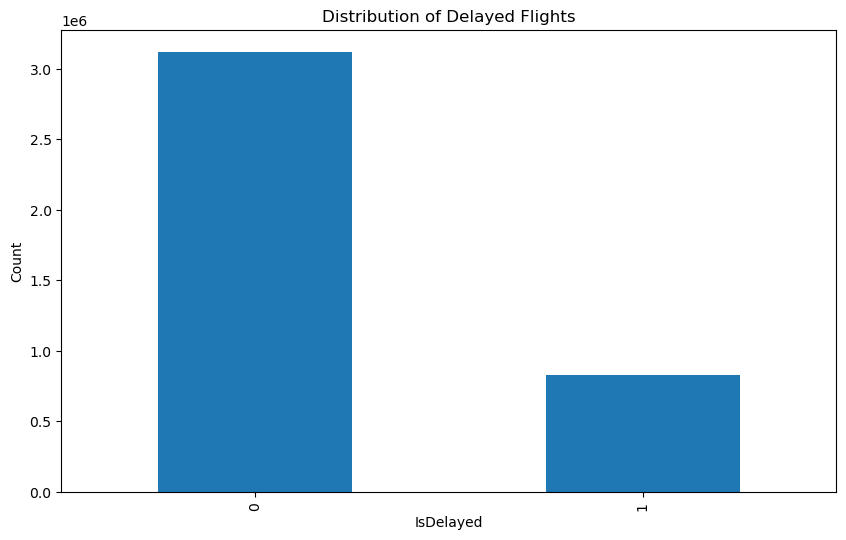

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['IsDelayed'].value_counts().plot(kind='bar')
plt.xlabel('IsDelayed')
plt.ylabel('Count')
plt.title('Distribution of Delayed Flights')
plt.show()

### The plot above shows a clear class imbalance, with far more on-time flights than delayed flights. This imbalance is important to keep in mind because it can affect model training and evaluation, especially for the delayed class.

In [8]:
X = df.drop('IsDelayed', axis=1)
y = df['IsDelayed']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Model Setup

Configure CatBoost with the categorical features and training hyperparameters.

In [10]:
from catboost import CatBoostClassifier

cat_features = ['Airline', 'Origin', 'Dest', 'Season', 'DepTimeOfDay']

In [13]:
cb_model = CatBoostClassifier(
    iterations=1000,                  
    learning_rate=0.1,               
    depth=6,                          
    cat_features=cat_features,        
    task_type='CPU',                   
    auto_class_weights='Balanced',# Helps balance the fact that most flights are on-time (0)
    random_seed=42,
    verbose=100                       # Print progress every 100 trees to avoid spamming the output
)

## Training

Fit the CatBoost model with early stopping on the validation set.

In [14]:
cb_model.fit(
    X_train, 
    y_train, 
    eval_set=(X_test, y_test), 
    early_stopping_rounds=50          # Stops training if the model stops improving
)

0:	learn: 0.6866580	test: 0.6866311	best: 0.6866311 (0)	total: 2.55s	remaining: 42m 24s
100:	learn: 0.6364495	test: 0.6346674	best: 0.6346674 (100)	total: 2m 50s	remaining: 25m 13s
200:	learn: 0.6328695	test: 0.6311209	best: 0.6311209 (200)	total: 6m 29s	remaining: 25m 49s
300:	learn: 0.6309814	test: 0.6294910	best: 0.6294910 (300)	total: 11m 58s	remaining: 27m 47s
400:	learn: 0.6295773	test: 0.6283071	best: 0.6283071 (400)	total: 17m 56s	remaining: 26m 48s
500:	learn: 0.6285417	test: 0.6275096	best: 0.6275096 (500)	total: 23m 13s	remaining: 23m 8s
600:	learn: 0.6277120	test: 0.6269223	best: 0.6269223 (600)	total: 28m 3s	remaining: 18m 37s
700:	learn: 0.6269709	test: 0.6263946	best: 0.6263946 (700)	total: 32m 52s	remaining: 14m 1s
800:	learn: 0.6263752	test: 0.6260342	best: 0.6260342 (800)	total: 37m 45s	remaining: 9m 22s
900:	learn: 0.6257300	test: 0.6256127	best: 0.6256127 (900)	total: 42m 38s	remaining: 4m 41s
999:	learn: 0.6252568	test: 0.6253585	best: 0.6253585 (999)	total: 47m 35

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['Airline', 'Origin', 'Dest', 'Season', 'DepTimeOfDay'], depth=6, iterations=1000, learning_rate=0.1, random_seed=42, task_type='CPU', verbose=100)

## Evaluation

Measure model quality with the classification report and compare it against a naive baseline.

In [15]:
y_pred = cb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.68      0.76    623758
           1       0.34      0.62      0.44    165226

    accuracy                           0.67    788984
   macro avg       0.60      0.65      0.60    788984
weighted avg       0.76      0.67      0.70    788984



In [16]:
naive_preds = np.zeros_like(y_test)  
naive_accuracy = (naive_preds == y_test).mean()
 
print(f"Naive baseline (always 'on time') accuracy: {naive_accuracy:.3f}")
print(f"Naive baseline recall on delayed flights:    0.000  <- catches ZERO delays")
print(f"Your CatBoost accuracy:                      {(y_pred == y_test).mean():.3f}")
print(f"Your CatBoost recall on delayed flights:      0.62   <- catches real delays")

Naive baseline (always 'on time') accuracy: 0.791
Naive baseline recall on delayed flights:    0.000  <- catches ZERO delays
Your CatBoost accuracy:                      0.668
Your CatBoost recall on delayed flights:      0.62   <- catches real delays


## Confusion Matrix

Visualize normalized prediction performance across the two classes.

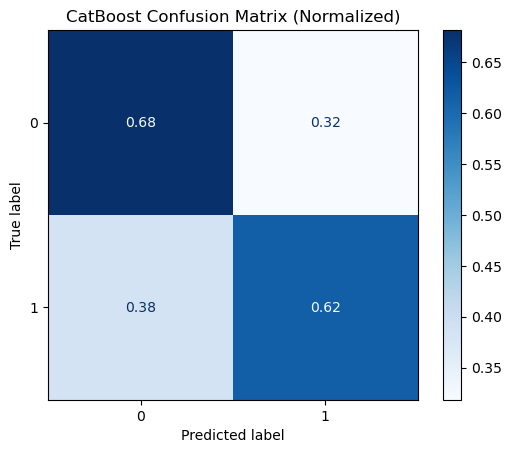

In [17]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap=plt.cm.Blues, 
    normalize='true'
)
plt.title("CatBoost Confusion Matrix (Normalized)")
plt.show()

## Feature Importance

Inspect which features contribute most to the model's delay predictions.


Feature importance:
CRSDepTime          16.037702
Airline             15.326674
Flight_DayOfWeek    13.244564
Origin              12.279975
Season              10.126300
Dest                 9.636037
Flight_Month         8.557532
CRSArrTime           6.451771
DepTimeOfDay         4.356014
Distance             2.840593
Is_Weekend           1.142836
dtype: float64


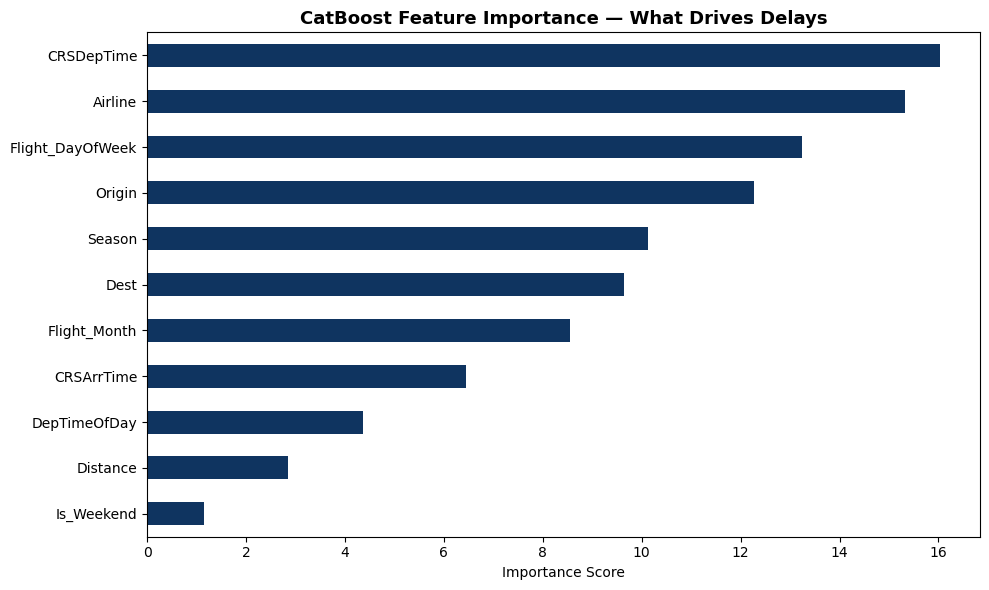

In [18]:
importance = pd.Series(
    cb_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)
 
print("\nFeature importance:")
print(importance)
 
plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind='barh', color='#0F3460')
plt.title("CatBoost Feature Importance — What Drives Delays", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from catboost import CatBoostRegressor

df_delayed = data[data['ArrDelay'] > 0].copy()

X = df_delayed[[
    'Airline', 'Origin', 'Dest', 'CRSDepTime', 'CRSArrTime',
    'Distance', 'Flight_Month', 'Flight_DayOfWeek', 'Is_Weekend',
    'Season', 'DepTimeOfDay'
]]
y = df_delayed['ArrDelay']

cat_features = ['Airline', 'Origin', 'Dest', 'Season', 'DepTimeOfDay']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
cb_regressor = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    task_type='CPU',
    random_seed=42,
    verbose=100,
    loss_function='RMSE'
)

In [16]:
cb_regressor.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

0:	learn: 77.6935476	test: 78.1786476	best: 78.1786476 (0)	total: 847ms	remaining: 14m 6s
100:	learn: 76.6366432	test: 77.1109705	best: 77.1109705 (100)	total: 55s	remaining: 8m 9s
200:	learn: 76.5412711	test: 77.0384305	best: 77.0384305 (200)	total: 1m 47s	remaining: 7m 7s
300:	learn: 76.4633324	test: 76.9894659	best: 76.9894659 (300)	total: 2m 45s	remaining: 6m 23s
400:	learn: 76.4209077	test: 76.9678939	best: 76.9678939 (400)	total: 4m 3s	remaining: 6m 3s
500:	learn: 76.3747054	test: 76.9457315	best: 76.9457315 (500)	total: 5m 23s	remaining: 5m 21s
600:	learn: 76.3351821	test: 76.9338683	best: 76.9338683 (600)	total: 6m 51s	remaining: 4m 33s
700:	learn: 76.2887566	test: 76.9131921	best: 76.9131917 (699)	total: 8m 13s	remaining: 3m 30s
800:	learn: 76.2511335	test: 76.8999154	best: 76.8999154 (800)	total: 9m 40s	remaining: 2m 24s
900:	learn: 76.2205153	test: 76.8927869	best: 76.8927869 (900)	total: 11m 4s	remaining: 1m 13s
999:	learn: 76.1928487	test: 76.8858991	best: 76.8858991 (999)

CatBoostRegressor(cat_features=['Airline', 'Origin', 'Dest', 'Season', 'DepTimeOfDay'], depth=6, iterations=1000, learning_rate=0.1, loss_function='RMSE', random_seed=42, task_type='CPU', verbose=100)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
preds = cb_regressor.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.2f} minutes")
print(f"RMSE: {mean_squared_error(y_test, preds, squared=False):.2f} minutes")
print(f"R²: {r2_score(y_test, preds):.3f}")

MAE: 38.22 minutes
RMSE: 76.89 minutes
R²: 0.036


C:\Users\asus\anaconda4\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


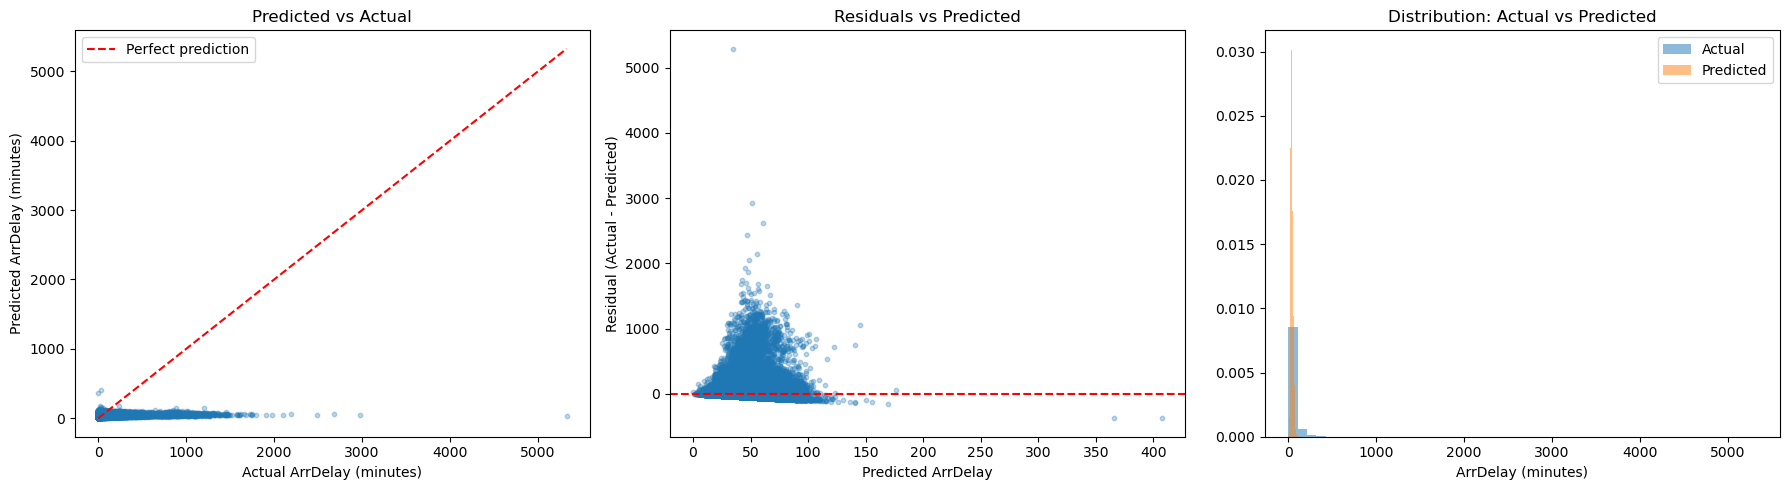

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Predicted vs Actual
axes[0].scatter(y_test, preds, alpha=0.3, s=10)
lims = [0, max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual ArrDelay (minutes)')
axes[0].set_ylabel('Predicted ArrDelay (minutes)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# 2) Residuals vs Predicted
residuals = y_test - preds
axes[1].scatter(preds, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted ArrDelay')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted')

# 3) Distribution comparison
axes[2].hist(y_test, bins=50, alpha=0.5, label='Actual', density=True)
axes[2].hist(preds, bins=50, alpha=0.5, label='Predicted', density=True)
axes[2].set_xlabel('ArrDelay (minutes)')
axes[2].set_title('Distribution: Actual vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.savefig('regressor_diagnostics.png', dpi=120)
plt.show()

## Saving the model for a wep app

In [19]:
cb_model.save_model('flight_delay_classifier.cbm')

In [ ]:
cb_regressor.save_model('flight_delay_regressor.cbm')

In [6]:
from sqlalchemy import create_engine

engine = create_engine('mysql+pymysql://root:@localhost:3308/sky_scope_db')

In [24]:
sample_data = data.sample(n=5, random_state=42)

In [ ]:
data.to_sql(
    'Flights',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=500,
    method='multi'
)

In [7]:
chunk_size = 1000

for i in range(0, len(data), chunk_size):
    chunk = data.iloc[i:i + chunk_size]
    chunk.to_sql(
        'Flights',
        con=engine,
        if_exists='append' if i > 0 else 'replace',
        index=False,
        method='multi'
    )
    print(f"Inserted {min(i + chunk_size, len(data))} / {len(data)} rows")

C:\Users\asus\AppData\Local\Temp\ipykernel_9404\1913621327.py:5: UserWarning: The provided table name 'Flights' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  chunk.to_sql(


Inserted 1000 / 4078318 rows
Inserted 2000 / 4078318 rows
Inserted 3000 / 4078318 rows
Inserted 4000 / 4078318 rows
Inserted 5000 / 4078318 rows
Inserted 6000 / 4078318 rows
Inserted 7000 / 4078318 rows
Inserted 8000 / 4078318 rows
Inserted 9000 / 4078318 rows
Inserted 10000 / 4078318 rows
Inserted 11000 / 4078318 rows
Inserted 12000 / 4078318 rows
Inserted 13000 / 4078318 rows
Inserted 14000 / 4078318 rows
Inserted 15000 / 4078318 rows
Inserted 16000 / 4078318 rows
Inserted 17000 / 4078318 rows
Inserted 18000 / 4078318 rows
Inserted 19000 / 4078318 rows
Inserted 20000 / 4078318 rows
Inserted 21000 / 4078318 rows
Inserted 22000 / 4078318 rows
Inserted 23000 / 4078318 rows
Inserted 24000 / 4078318 rows
Inserted 25000 / 4078318 rows
Inserted 26000 / 4078318 rows
Inserted 27000 / 4078318 rows
Inserted 28000 / 4078318 rows
Inserted 29000 / 4078318 rows
Inserted 30000 / 4078318 rows
Inserted 31000 / 4078318 rows
Inserted 32000 / 4078318 rows
Inserted 33000 / 4078318 rows
Inserted 34000 / 40